## Importing cleaned dataset

In [67]:
# Load the dataset
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
import joblib

df = pd.read_csv("../data/processed/jiji_smartphones_clean.csv")
print(df.head())

     Brand  Storage Condition                       Location   Price  \
0   iPhone      256       New              Addis Ababa, Bole   79500   
1  Samsung      512       New  Addis Ababa, Nifas Silk-Lafto   85000   
2   iPhone      128       New              Addis Ababa, Bole   78500   
3   iPhone      256       New              Addis Ababa, Bole  121000   
4   iPhone      512      Used              Addis Ababa, Bole  110500   

              Model  Class  Brand_code  Location_code  Model_code  \
0     iPhone 14 256      0           1              2          15   
1  Galaxy S23 Ultra      1           0              4           1   
2    iPhone 14 Plus      0           1              2          16   
3     iPhone 15 Pro      1           1              2          21   
4     iPhone 14 Pro      1           1              2          17   

   Condition_code  
0               0  
1               0  
2               0  
3               0  
4               1  


## Create Log Target

A log transformation was applied to the target variable to reduce skewness and improve model performance. A Linear Regression model was trained on the transformed data, and predictions were converted back to the original scale for evaluation.

In [68]:
import numpy as np

df["LogPrice"] = np.log(df["Price"])

## Define Features and Target

In [69]:
X = df.drop(["Price", "LogPrice", "Class"], axis=1)
y = df["LogPrice"]

## Train-Test Split

In [70]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Scaling Training

In [71]:
cat_features = ['Brand', 'Location', 'Model', 'Condition']
num_features = ['Storage']

preprocessor = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features),
    ("num", StandardScaler(), num_features)
])

reg_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])

reg_pipeline.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformer

## Predict

In [72]:
y_pred_log = reg_pipeline.predict(X_test)

## Convert back to real prices
since trained on log

In [73]:
y_pred = np.exp(y_pred_log)
y_actual = np.exp(y_test)

## Evaluate Model

In [74]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

rmse = np.sqrt(mean_squared_error(y_actual, y_pred))
r2 = r2_score(y_actual, y_pred)

print("RMSE:", rmse)
print("R² Score:", r2)

RMSE: 10225.516330641285
R² Score: 0.8965095042710911


## Visualization

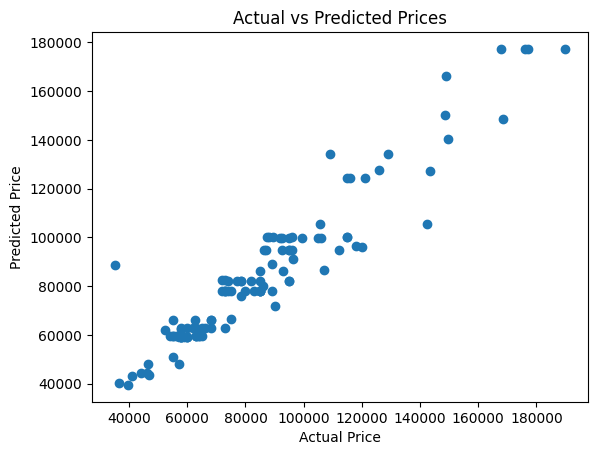

In [75]:
import matplotlib.pyplot as plt

plt.scatter(y_actual, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Prices")
plt.show()

The Linear Regression model achieved an R² score of approximately 0.89, indicating that the model explains a significant portion of the variance in smartphone prices. The RMSE value of around 12,226 ETB suggests that the model predictions are reasonably accurate given the wide price range. The scatter plot of actual vs. predicted values shows a strong linear relationship, although greater variance is observed at higher price ranges, indicating reduced accuracy for premium devices.

## Hyperparameter Tuning with Bayesian Optimization

Linear Regression does not require extensive hyperparameter tuning, as it has very few configurable parameters compared to more complex models. The default configuration already provides an optimal closed-form solution for minimizing error. Therefore, additional tuning was not necessary, and model performance was instead improved through feature engineering and log transformation of the target variable.

## Saving Regression Model

In [78]:
joblib.dump(reg_pipeline, "../models/reg_pipeline.pkl")
print("Regression pipeline (log-price) saved!")

Regression pipeline (log-price) saved!
